## Using AraVec Embeddings for Arabic Sentiment Classification

This example demonstrates how to use AraVec word embeddings with a dataset containing Arabic text and sentiment labels (positive, negative, neutral). The workflow includes:
1. Loading the dataset.
2. Preprocessing and tokenizing the text.
3. Loading AraVec and building an embedding matrix.
4. Building and training a Keras model using the AraVec embeddings.

In [1]:
import pandas as pd
import numpy as np
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec


In [2]:

# 1. Load your dataset (should have columns: 'Text', 'Sentiment')
file_path = r"train_araCovid_sentiment.tsv"
df = pd.read_csv(file_path, encoding='utf-8', sep='\t')


In [3]:
import nltk
from nltk.corpus import stopwords
# 2. Preprocess text (simple cleaning)
def clean_text(text):
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove hachtags
    text = re.sub(r'#\w+', '', text)
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    # Remove emojis
    text = re.sub(r'[^\w\s,]', '', text)
    # Remove numbers with 3 or more consecutive digits
    text = re.sub(r'\d{3,}', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove non-Arabic words
    text = re.sub(r'[^ا-ي\s]', '', text)
    # Remove stop words (Arabic) using nltk
    try:
        arabic_stopwords = set(stopwords.words('arabic'))
    except LookupError:
        nltk.download('stopwords')
        arabic_stopwords = set(stopwords.words('arabic'))
    text = ' '.join([word for word in text.split() if word not in arabic_stopwords])
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text
df['cleaned_text'] = df['Text'].astype(str).apply(clean_text)
df = df[df['cleaned_text'].str.strip() != '']


In [4]:
# 3. Encode sentiment labels
label_map = {'positive': 0, 'negative': 1, 'neutral': 2}
df['label'] = df['sentiment'].str.lower().map(label_map)
y = to_categorical(df['label'], num_classes=3)


In [5]:
# Combine all comments into a single string
all_texts = " ".join(df['cleaned_text'].dropna().astype(str))

# Extract all words using regex
words = re.findall(r'\S+', all_texts)
    
# Get unique words
corpus = set(words)

print("All unique words in the 'cleaned_text' column:")
print(corpus)

All unique words in the 'cleaned_text' column:
{'حيلتنا', 'وريبا', 'ورا', 'الطريق', 'وتبين', 'دريت', 'فتكدوا', 'جنن', 'السالفه', 'نيويورك', 'حبيبي', 'بيعرفوا', 'بختصار', 'والذن', 'هالمرض', 'وكحة', 'باالله', 'كشعب', 'يشوفون', 'يكون', 'وحط', 'فراق', 'القناع', 'منعدمين', 'مغلقه', 'الثانية', 'واحفظها', 'ونتضرع', 'واياكم', 'اول', 'اتبع', 'حيله', 'سنرمي', 'وعطوني', 'القمامة', 'نرى', 'خصم', 'ايشيله', 'التقاط', 'ملم', 'مصعد', 'المعدنية', 'نزلا', 'والخطايا', 'زارتني', 'نتكلم', 'بخجل', 'اداوم', 'تكفووون', 'الطالب', 'والتقيد', 'لسخرية', 'كساوحتماسوف', 'عاقبهم', 'موسى', 'بضل', 'سيرجع', 'زوال', 'ملاحظة', 'سنسمع', 'بدون', 'جم', 'وم', 'والساهرين', 'شيبقدر', 'بالسن', 'عالاتكم', 'لتهذبنا', 'السما', 'النكت', 'النتيجة', 'العشرية', 'منظمةمستشفيات', 'تلاقيك', 'ترضى', 'حجمنا', 'بعرس', 'حالتهاالطبيعيه', 'ورحمه', 'وناجحه', 'حال', 'يتخر', 'فرض', 'الاتصال', 'واذناب', 'والجبروتواعتصمت', 'واجعلة', 'عراض', 'وقوهم', 'بنكم', 'والديكم', 'برعايتك', 'تبحث', 'الاعتماد', 'تنفسنا', 'تخسر', 'الموت', 'خبركم', 'وبدله', 'مسكر

In [6]:
max_words = len(corpus)  # +1 for OOV token
max_len = 50
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_text'])
sequences = tokenizer.texts_to_sequences(df['cleaned_text'])
X = pad_sequences(sequences, maxlen=max_len, padding='post')


In [7]:
# 5. Load AraVec model (only to get embedding_dim, not used in Embedding layer)
aravec_path = r'full_grams_cbow_300_twitter.mdl'  # update path as needed
aravec_model = Word2Vec.load(aravec_path)
embedding_dim = aravec_model.vector_size


In [8]:
import numpy as np

word_index = tokenizer.word_index

# Create embedding matrix
embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))

for word, i in word_index.items():
    if word in aravec_model.wv:
        embedding_matrix[i] = aravec_model.wv[word]
    else:
        embedding_matrix[i] = np.random.normal(size=(embedding_dim,))  # for OOV

# Now your X has shape (num_samples, 50), and each token is an index
# To get (num_samples, 50, 300), use embedding_matrix:
X_embed = embedding_matrix[X]


In [9]:
# 7. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
# Convert X_train to a DataFrame for better visualization
pd.DataFrame(X_train).head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,518,8,89,2699,1369,459,42,51,63,2,...,0,0,0,0,0,0,0,0,0,0
1,214,2683,67,511,2666,1084,22,256,723,2386,...,0,0,0,0,0,0,0,0,0,0
2,3,37,237,1440,191,11,1187,1996,1399,1423,...,0,0,0,0,0,0,0,0,0,0
3,12228,1417,2174,5091,255,2875,187,3368,1055,0,...,0,0,0,0,0,0,0,0,0,0
4,3607,1568,661,1569,1570,1571,88,348,1572,1573,...,0,0,0,0,0,0,0,0,0,0


Epoch 1/100


c:\Users\DELL\Desktop\SA\myenv\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 134ms/step - accuracy: 0.4272 - loss: 2.2413 - val_accuracy: 0.5438 - val_loss: 1.5736 - learning_rate: 0.0010
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.6392 - loss: 1.3873 - val_accuracy: 0.6133 - val_loss: 1.1673 - learning_rate: 0.0010
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.8396 - loss: 0.9880 - val_accuracy: 0.8489 - val_loss: 0.8920 - learning_rate: 0.0010
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - accuracy: 0.9324 - loss: 0.7351 - val_accuracy: 0.8399 - val_loss: 0.7556 - learning_rate: 0.0010
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.9410 - loss: 0.5724 - val_accuracy: 0.8338 - val_loss: 0.7216 - learning_rate: 0.0010
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - accuracy: 0.9583 - loss: 0.4840 - val_accuracy: 0.8369 - val_loss: 0.6361 - learning_rate: 0.0010
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.9656 - loss: 0.3742 - val_

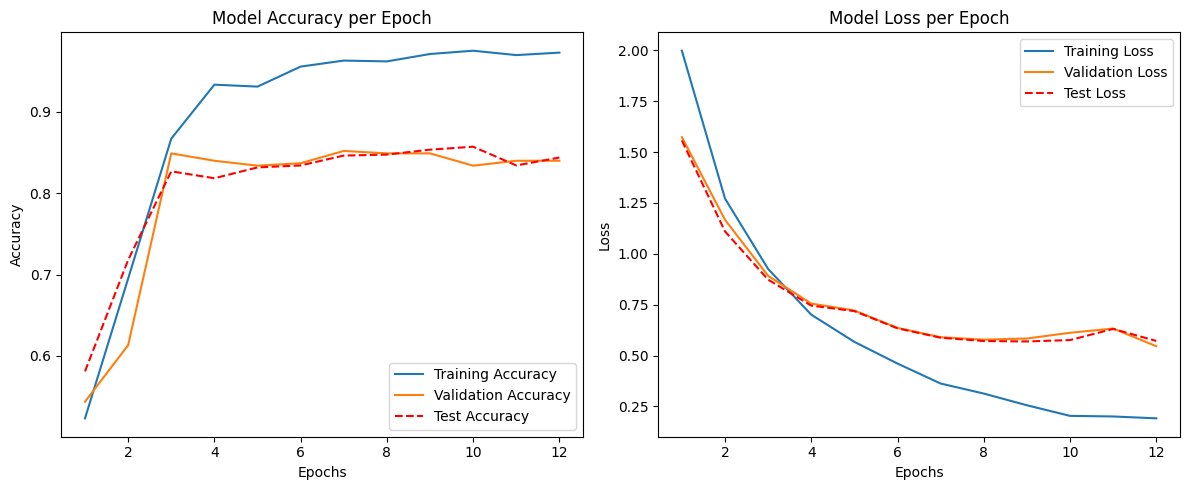

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step

Final Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.83      0.89       339
           1       0.81      0.81      0.81       189
           2       0.77      0.89      0.83       298

    accuracy                           0.85       826
   macro avg       0.85      0.84      0.84       826
weighted avg       0.86      0.85      0.85       826



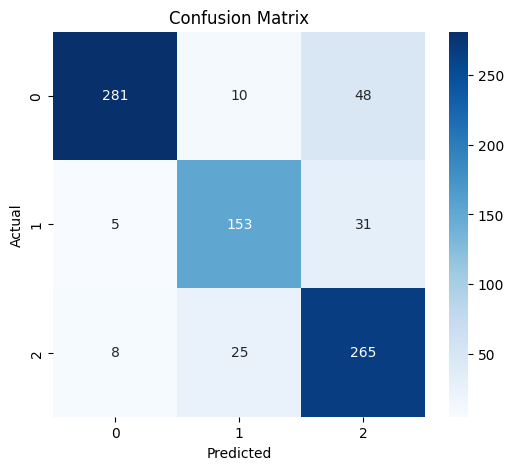

In [19]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, Callback
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# BLSTM model without pre-trained weights (trainable embedding)

model2 = Sequential()
model2.add(Embedding(input_dim=max_words,
                     output_dim=embedding_dim,
                     input_length=max_len,
                     trainable=True))  # No weights argument, trainable embeddings
model2.add(Dropout(0.2))
model2.add(Bidirectional(LSTM(8, return_sequences=True, kernel_regularizer='l2')))
model2.add(Dropout(0.2))
model2.add(Bidirectional(LSTM(4, return_sequences=False, kernel_regularizer='l2')))
model2.add(Dense(3, activation='softmax'))
model2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Training the new model
# Set up ReduceLROnPlateau callback for learning rate adjustment

class TestPerformanceCallback(Callback):
    def __init__(self, X_test, y_test):
        super().__init__()
        self.X_test = X_test
        self.y_test = y_test
        self.test_accuracies = []
        self.test_losses = []

    def on_epoch_end(self, epoch, logs=None):
        loss, acc = self.model.evaluate(self.X_test, self.y_test, verbose=0)
        self.test_accuracies.append(acc)
        self.test_losses.append(loss)

reduce_lr = ReduceLROnPlateau(monitor='accuracy', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
test_callback = TestPerformanceCallback(X_test, y_test)

history = model2.fit(
    X_train, y_train,  # Make sure y_train_cat is used here (one-hot)
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr, test_callback]
)

loss, accuracy = model2.evaluate(X_test, y_test)  # Make sure y_test_cat is used here (one-hot)
print(f"Test Accuracy: {accuracy:.2f}")

epochs_range = range(1, len(history.history['accuracy']) + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(epochs_range, test_callback.test_accuracies, label='Test Accuracy', linestyle='dashed', color='red')
plt.title('Model Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Training Loss')
plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss')
plt.plot(epochs_range, test_callback.test_losses, label='Test Loss', linestyle='dashed', color='red')
plt.title('Model Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Predict and evaluate final model
y_pred = model2.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)  # Use y_test_cat for one-hot

print("\nFinal Classification Report:")
print(classification_report(y_true_classes, y_pred_classes))

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Convert one-hot encoded labels to class indices for training
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, np.argmax(y_train, axis=1))

# Make predictions and evaluate the model
y_pred_dt = dt_model.predict(X_test)
print(classification_report(np.argmax(y_test, axis=1), y_pred_dt))
print("Accuracy:", accuracy_score(np.argmax(y_test, axis=1), y_pred_dt))

              precision    recall  f1-score   support

           0       0.76      0.74      0.75       339
           1       0.75      0.77      0.76       189
           2       0.74      0.75      0.74       298

    accuracy                           0.75       826
   macro avg       0.75      0.75      0.75       826
weighted avg       0.75      0.75      0.75       826

Accuracy: 0.7506053268765133


Epoch 1/100


c:\Users\DELL\Desktop\SA\myenv\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


43/47 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4054 - loss: 1.3202Epoch 1: Test accuracy = 0.5182, Test loss = 1.1819
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4084 - loss: 1.3153 - val_accuracy: 0.4622 - val_loss: 1.1939
Epoch 2/100
45/47 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5146 - loss: 1.1494Epoch 2: Test accuracy = 0.6271, Test loss = 0.9327
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5165 - loss: 1.1457 - val_accuracy: 0.5952 - val_loss: 0.9443
Epoch 3/100
45/47 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6606 - loss: 0.8499Epoch 3: Test accuracy = 0.8232, Test loss = 0.6686
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6620 - loss: 0.8453 - val_accuracy: 0.8218 - val_loss: 0.6658
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8187 - loss: 0.5761Epoch 4: Test accuracy = 0.8692, Test loss = 0.5058
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8193 - loss: 0.5750 - val_accuracy: 0.8520 - val_loss: 0.5258


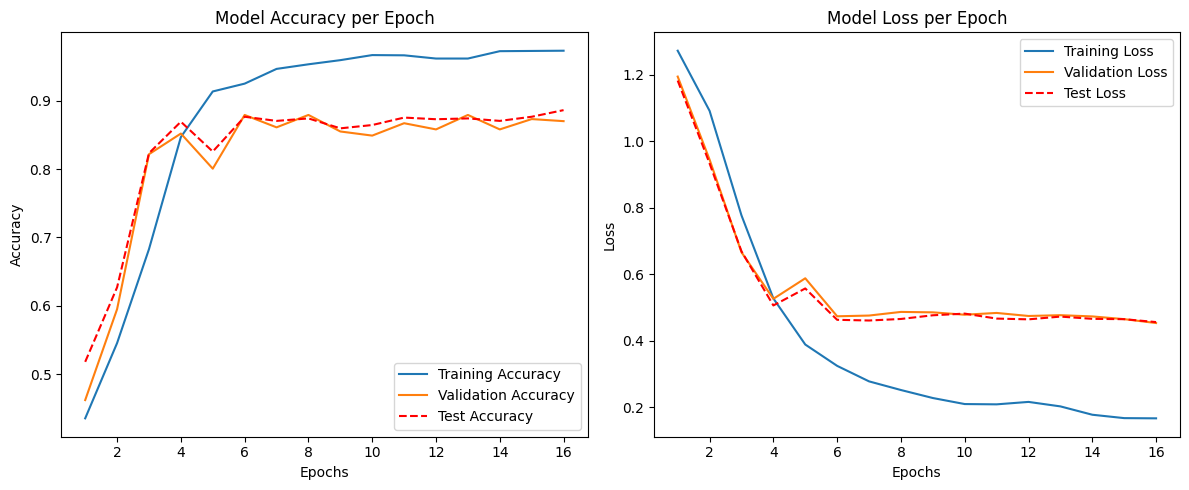

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Final Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       339
           1       0.84      0.86      0.85       189
           2       0.86      0.87      0.87       298

    accuracy                           0.88       826
   macro avg       0.87      0.87      0.87       826
weighted avg       0.88      0.88      0.88       826



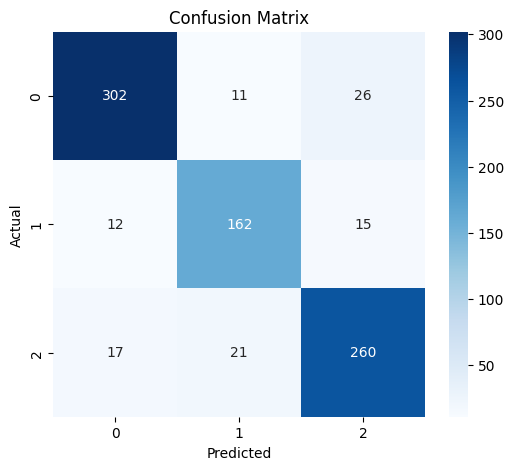

In [40]:

from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dropout, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, Callback

# Custom callback to evaluate on test data after each epoch
class TestPerformanceCallback(Callback):
    def __init__(self, X_test, y_test):
        super().__init__()
        self.X_test = X_test
        self.y_test = y_test
        self.test_accuracies = []
        self.test_losses = []

    def on_epoch_end(self, epoch, logs=None):
        loss, acc = self.model.evaluate(self.X_test, self.y_test, verbose=0)
        self.test_losses.append(loss)
        self.test_accuracies.append(acc)
        print(f"Epoch {epoch+1}: Test accuracy = {acc:.4f}, Test loss = {loss:.4f}")

# Define the model model using an Embedding layer and GlobalAveragePooling1D
model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    GlobalAveragePooling1D(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(3, activation='softmax', kernel_regularizer=l2(0.001))
])


# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
test_callback = TestPerformanceCallback(X_test, y_test)

# Train the model (with validation split and test tracking)
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=64,
                    validation_split=0.1,
                    callbacks=[early_stop, test_callback])


# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")

# Plot training, validation, and test metrics
epochs_range = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(epochs_range, test_callback.test_accuracies, label='Test Accuracy', linestyle='dashed', color='red')
plt.title('Model Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Training Loss')
plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss')
plt.plot(epochs_range, test_callback.test_losses, label='Test Loss', linestyle='dashed', color='red')
plt.title('Model Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Predict and evaluate final model
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\nFinal Classification Report:")
print(classification_report(np.argmax(y_test, axis=1), y_pred_classes))

cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



Epoch 1/100


c:\Users\DELL\Desktop\SA\myenv\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 734ms/step - accuracy: 0.4138 - loss: 11.4444 - val_accuracy: 0.4804 - val_loss: 9.9471 - learning_rate: 0.0010
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 484ms/step - accuracy: 0.5269 - loss: 9.5072 - val_accuracy: 0.5287 - val_loss: 8.2172 - learning_rate: 0.0010
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 460ms/step - accuracy: 0.5835 - loss: 7.8177 - val_accuracy: 0.6949 - val_loss: 6.7187 - learning_rate: 0.0010
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 442ms/step - accuracy: 0.7773 - loss: 6.3468 - val_accuracy: 0.7372 - val_loss: 5.4867 - learning_rate: 0.0010
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 449ms/step - accuracy: 0.8235 - loss: 5.1231 - val_accuracy: 0.7915 - val_loss: 4.4803 - learning_rate: 0.0010
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 462ms/step - accuracy: 0.8758 - loss: 4.1268 - val_accuracy: 0.8308 - val_loss: 3.6585 - learning_rate: 0.0010
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 464ms/step - accuracy: 0.9266 - loss: 3.2924 - val_accuracy: 0.82

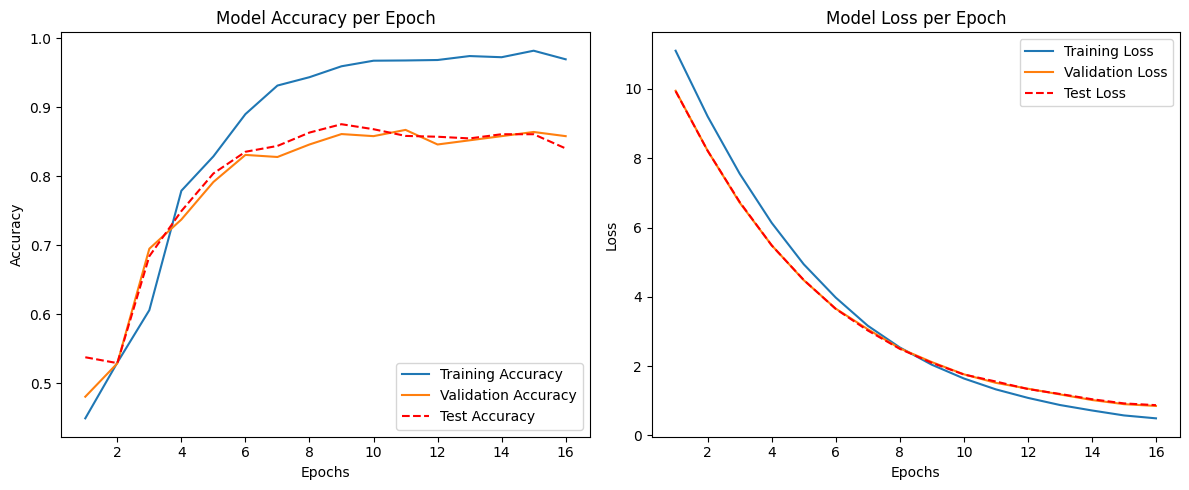

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step

Final Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.83      0.89       339
           1       0.75      0.88      0.81       189
           2       0.85      0.87      0.86       298

    accuracy                           0.86       826
   macro avg       0.85      0.86      0.85       826
weighted avg       0.87      0.86      0.86       826



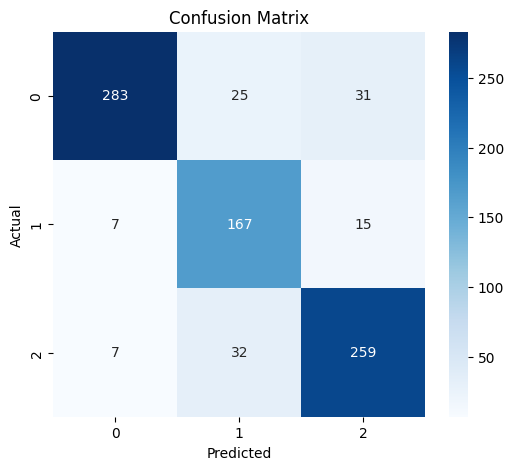

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, Callback
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# BLSTM model without pre-trained weights (trainable embedding)
model2 = Sequential()
model2.add(Embedding(input_dim=max_words,
                     output_dim=embedding_dim,
                     input_length=max_len,
                     trainable=True))  # No weights argument, trainable embeddings
model2.add(Dropout(0.2))
model2.add(Bidirectional(LSTM(128, return_sequences=True, kernel_regularizer='l2')))
model2.add(Dropout(0.2))
model2.add(Bidirectional(LSTM(30, return_sequences=False, kernel_regularizer='l2')))
model2.add(Dense(3, activation='softmax'))
model2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Training the new model
# Set up ReduceLROnPlateau callback for learning rate adjustment

class TestPerformanceCallback(Callback):
    def __init__(self, X_test, y_test):
        super().__init__()
        self.X_test = X_test
        self.y_test = y_test
        self.test_accuracies = []
        self.test_losses = []

    def on_epoch_end(self, epoch, logs=None):
        loss, acc = self.model.evaluate(self.X_test, self.y_test, verbose=0)
        self.test_accuracies.append(acc)
        self.test_losses.append(loss)

reduce_lr = ReduceLROnPlateau(monitor='accuracy', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
test_callback = TestPerformanceCallback(X_test, y_test)

history = model2.fit(
    X_train, y_train,  # Make sure y_train_cat is used here (one-hot)
    epochs=100,
    batch_size=512,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr, test_callback]
)

loss, accuracy = model2.evaluate(X_test, y_test)  # Make sure y_test_cat is used here (one-hot)
print(f"Test Accuracy: {accuracy:.2f}")

epochs_range = range(1, len(history.history['accuracy']) + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(epochs_range, test_callback.test_accuracies, label='Test Accuracy', linestyle='dashed', color='red')
plt.title('Model Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Training Loss')
plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss')
plt.plot(epochs_range, test_callback.test_losses, label='Test Loss', linestyle='dashed', color='red')
plt.title('Model Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Predict and evaluate final model
y_pred = model2.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)  # Use y_test_cat for one-hot

print("\nFinal Classification Report:")
print(classification_report(y_true_classes, y_pred_classes))

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()